# System Setup

In [4]:
import numpy as np
import mdtraj as md
import pandas as pd
import nglview as nv
import seaborn as sns
import os

## Protein structure and sequence preparation

In [2]:
!ls

01_interface_visualisation.ipynb  B2  B4  B5  model.log


### B2

In [5]:
os.chdir('B2')

Ibrahim already gave the `2o98.pdb` from the paper

In [7]:
!ls

2o98.fasta			 o98.B99990004.pdb  o98.sch
2o98.pdb			 o98.B99990005.pdb  o98_solvent.pdb
amber_o98.B99990002_nonprot.pdb  o98.D00000001	    o98.V99990001
amber_o98.B99990002.pdb		 o98.D00000002	    o98.V99990002
amber_o98.B99990002_renum.txt	 o98.D00000003	    o98.V99990003
amber_o98.B99990002_sslink	 o98.D00000004	    o98.V99990004
model.log			 o98.D00000005	    o98.V99990005
model.py			 o98.fasta	    original
o98.ali				 o98.ini	    salign.log
o98.B99990001.pdb		 o98.pap	    salign.py
o98.B99990002.pdb		 o98.pdb
o98.B99990003.pdb		 o98.rsr


#### Visualize original `.pdb` structure

In [7]:
path2ogpdb = '2o98.pdb'
pdb2o98 = md.load(path2ogpdb)
pdb2o98_df, _ = pdb2o98.topology.to_dataframe()
display(pdb2o98_df)

,serial,name,element,resSeq,resName,chainID,segmentID
0,1,N,N,2,ALA,0,
1,2,CA,C,2,ALA,0,
2,3,C,C,2,ALA,0,
3,4,O,O,2,ALA,0,
4,5,CB,C,2,ALA,0,
...,...,...,...,...,...,...,...
4808,4824,O,O,80,HOH,9,
4809,4825,O,O,84,HOH,9,
4810,4826,O,O,103,HOH,9,
4811,4827,O,O,120,HOH,9,


In [30]:
print(pdb2o98_df.chainID.unique())

[0 1 2 3 4 5 6 7 8 9]


In [14]:
view = nv.show_mdtraj(pdb2o98)
# view.add_licorice(selection="all",opacity=1,radius=0.3)
view

NGLWidget()

#### Extract target proteins and solvent

Extract chains A and P from `2o98.pdb`

Use VMD to obtain the chains that the paper modelled
1. representation: Cartoon $\rightarrow$ shows alpha helices as cylinders (as in the paper)
2. colouring method: Chain

In [31]:
!grep -E 'ATOM\s+[0-9]+\s+[A-Z]+\s+[A-Z]+\s+A' 2o98.pdb > o98.pdb
!echo "TER" >> o98.pdb
!grep -E 'ATOM\s+[0-9]+\s+[A-Z]+\s+[A-Z]+\s+P' 2o98.pdb >> o98.pdb

Extract other atoms (e.g., Fusicoccin, water, ...) as "solvent" for running the simulation

In [32]:
!grep 'HETATM' 2o98.pdb > o98_solvent.pdb

#### Sequence alignment

Download protein sequence `2o98.fasta` from PDB (https://www.rcsb.org/3d-view/2o98/)

Create a new `o98.fasta` with the following contents:
```fasta
>P1;o98
sequence:o98:::::::0.00:0.00
<CHAIN-A-SEQUENCE>/
<CHAIN-P-SEQUENCE>*
```
where `<CHAIN-A-SEQUENCE>` and `<CHAIN-P-SEQUENCE>` are obtained from the downloaded `2o98.fasta` file

Align sequences with `salign.py` which has been hardcoded with the `o98` PDB ID

Ignore `'import site' failed` messages given by `modeller`

In [33]:
!mod10.4 salign.py

'import site' failed; use -v for traceback


Manually edit (e.g., on VS Code editor) the output `o98.ali` file's first entry (`>P1;o98_structure`, i.e., sequence from `.pdb` file)\
to match the missing (greyed) residues shown in PDB website

Usually the problems are at the chain breaks, e.g.,
- before: `M/-TNFNELNQL`
- fixed: `M-/TNFNELNQL`

#### Modelling the missing residues

Run `model.py` (hardcoded with `o98`) with `modeller` to construct (extrapolate) the coordinates of the missing residues

In [35]:
!mod10.4 model.py

'import site' failed; use -v for traceback


~~Run the "fixed" (i.e., takes in PDB ID as terminal arguments instead of hardcoding) `model.py` to construct (extrapolate) the coordinates of the missing residues~~

DOES NOT WORK\
`import argparse` works in python shell without any conda package installations \$\rightarrow$ seems like `modeller` only takes in a python script as argument

In [34]:
!mod10.4 ../model.py o98

'import site' failed; use -v for traceback
Traceback (most recent call last):
  File "../model.py", line 12, in ?
    import argparse
ImportError: No module named argparse


Check the final energy of all generated structures (access `tail -n 10` of all files that start with `o98.D`)

In [36]:
!tail -n 10 o98.D*

==> o98.D00000001 <==
    280       3214.15723   0.0323   0.0941       2586.60400        369.82132
    290       3300.17407   0.0319   0.1062       2529.61719        361.67358
    300       3278.58716   0.0318   0.0881       2527.89722        361.42767
# Conjugate gradients optimization
#  Step   Current energy Av shift Mx shift   Funcs         Gradient
      0       3278.58716   0.0000   0.0000       1      3.61788e+06
     10       1223.01990   0.0123   0.0506      21          59423.6
     20       1028.95776   0.0125   0.0773      42          43607.8
     30        953.12952   0.0045   0.0369      62          14618.6
     40        907.43365   0.0035   0.0248      82          7174.85

==> o98.D00000002 <==
    300       5330.88770   0.0283   0.6544       4794.88379        685.55151
# Conjugate gradients optimization
#  Step   Current energy Av shift Mx shift   Funcs         Gradient
      0       5330.88770   0.0000   0.0000       1      1.66417e+07
     10       1328.10217   0.0085

DOPE score can be checked in `model.log`

In [37]:
!tail -n 10 model.log

>> Summary of successfully produced models:
Filename                          molpdf     DOPE score
-------------------------------------------------------
o98.B99990001.pdb              879.55591   -32418.82422
o98.B99990002.pdb              877.03992   -32713.64648
o98.B99990003.pdb              909.06580   -32405.95117
o98.B99990004.pdb              974.72076   -32362.61914
o98.B99990005.pdb              902.67889   -32668.38867

Total CPU time [seconds]                                 :      34.46


Model 2 (`o98.B99990002.pdb`) is the best performer since it has the lowest (`molpdf` and) `DOPE score`

EXTRA:

Is AlphaFold a better model to get the structure of the full protein sequence with missing residues?

Test the following sequence on ColabFold (alphafold2_multimer_v3 with MMseqs2):
```py
MAVAPTAREENVYMAKLAEQAERYEEMVEFMEKVSNSLGSEELTVEERNLLSVAYKNVIGARRASWRIISSIEQKEESRGNEEHVNSIREYRSKIENELSKICDGILKLLDAKLIPSAASGDSKVFYLKMKGDYHRYLAEFKTGAERKEAAESTLTAYKAAQDIATTELAPTHPIRLGLALNFSVFYYEILNSPDRACNLAKQAFDEAIAELDTLGEESYKDSTLIMQLLRDNLTLWTSDMQ:TNFNELNQLAEEAKRRAEIARQRELHTLKGHVESVVKLKGLDIETIQQSYDI
```
- `:` denotes the chain break
- there should NOT be `*` in the sequence (unlike monomers)

AF2 predicts low confidence for the predicted ATPase (chain P) structure...\
But we only have missing residues in chain A? \
Can we use AF2 output coordinates in the `.pdb` file used downstream?

#### Changing residue names for MD simulation

Check if there are disulfide bonds in the original `2o98.pdb` either using `grep` or in VS Code editor

In [45]:
!grep 'SSBOND' 2o98.pdb

NO output $\rightarrow$ NO disulfide bonds $\rightarrow$ Do NOT have to run `pdb4amber`?

In [46]:
!pdb4amber -i o98.B99990002.pdb -o amber_o98.B99990002.pdb


Summary of pdb4amber for: o98.B99990002.pdb

----------Chains
The following (original) chains have been found:
A
B

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
None
-----------Non-standard-resnames


---------- Missing heavy atom(s)

None


Compare `o98.B99990002.pdb` and `amber_o98.B99990002.pdb`

In [9]:
!diff o98.B99990002.pdb amber_o98.B99990002.pdb

1,2359c1,2350
< EXPDTA    THEORETICAL MODEL, MODELLER 10.4 2024/06/07 13:39:14
< REMARK   6 MODELLER OBJECTIVE FUNCTION:       877.0399
< REMARK   6 MODELLER BEST TEMPLATE % SEQ ID: 100.000
< REMARK   6 SEQUENCE: o98
< REMARK   6 ALIGNMENT: o98.ali
< REMARK   6 SCRIPT: model.py
< REMARK   6 DOPE score: -32713.64648
< REMARK   6 TEMPLATE: o98_structure 2:A - 241:A MODELS 2:A - 241:A AT 100.0%
< REMARK   6 TEMPLATE: o98_structure 905:P - 956:P MODELS 243:B - 294:B AT 100.0%
< ATOM      1  N   MET A   1      28.719 106.648 107.896  1.00 92.47           N
< ATOM      2  CA  MET A   1      29.999 105.906 107.922  1.00 92.47           C
< ATOM      3  CB  MET A   1      31.115 106.810 108.471  1.00 92.47           C
< ATOM      4  CG  MET A   1      31.401 108.025 107.585  1.00 92.47           C
< ATOM      5  SD  MET A   1      32.555 109.232 108.303  1.00 92.47           S
< ATOM      6  CE  MET A   1      31.355 109.915 109.483  1.00 92.47           C
< ATOM      7  C   MET A   1      29.

## Protein Visualization and read Residue ID 

Load data from the `o98.B99990002.pdb` file with `mdtraj` module and save it as `pandas df`

In [57]:
path2AP_o98 = 'o98.B99990002.pdb'
AP_o98 = md.load(path2AP_o98)
AP_o98_df, _ = AP_o98.topology.to_dataframe()
display(AP_o98_df)

,serial,name,element,resSeq,resName,chainID,segmentID
0,1,N,N,1,MET,0,
1,2,CA,C,1,MET,0,
2,3,CB,C,1,MET,0,
3,4,CG,C,1,MET,0,
4,5,SD,S,1,MET,0,
...,...,...,...,...,...,...,...
2343,2345,CG2,C,294,ILE,1,
2344,2346,CD1,C,294,ILE,1,
2345,2347,C,C,294,ILE,1,
2346,2348,O,O,294,ILE,1,


Visualization of the protein chains in `o98.B99990002.pdb`

In [71]:
view = nv.show_mdtraj(AP_o98)
view

NGLWidget()

Get total number of atoms in each chain

In [58]:
A_num = AP_o98_df.query('chainID == 0').shape[0]
P_num = AP_o98_df.query('chainID == 1').shape[0]
print(A_num, P_num)

1923 425


Get unique residue numbers

In [59]:
A_resid = AP_o98_df.query('chainID == 0').resSeq.unique()
P_resid = AP_o98_df.query('chainID == 1').resSeq.unique()
print(A_resid, P_resid, sep='\n')

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242]
[243 244 245 246 

Get atomic coordinates

In [60]:
A_xyz = AP_o98.xyz[:,:A_num][0]
P_xyz = AP_o98.xyz[:,-P_num:][0]
print(A_xyz, P_xyz, sep='\n')

[[ 2.8719 10.6648 10.7896]
 [ 2.9999 10.5906 10.7922]
 [ 3.1115 10.681  10.8471]
 ...
 [-1.9969  6.4089 12.4349]
 [-1.9576  6.4623 12.3275]
 [-2.0728  6.308  12.4401]]
[[-2.878  10.2815 11.6197]
 [-2.9232 10.2124 11.7425]
 [-2.8891 10.0665 11.7356]
 ...
 [ 0.4043  7.5951 11.9517]
 [ 0.4721  7.5165 12.0232]
 [ 0.4412  7.6369 11.8387]]


Visualize the interatomic distance between A and B

In [53]:
from scipy.spatial.distance import cdist

<AxesSubplot:>

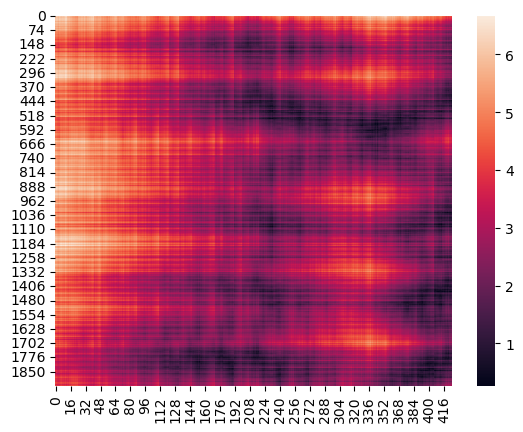

In [54]:
sns.heatmap(cdist(A_xyz, P_xyz))

Calculate the interface residue

In [55]:
cutoff = 0.5 
# boolean pair matrix specifying contact or not with 1 or 0 at the respective matrix element
bool_iatoms = (cdist(A_xyz, P_xyz) < cutoff).astype(int)
print(bool_iatoms)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Get the indices of interface atoms with `np.where()` and only keep the unique ones

In [61]:
A_iatoms, P_iatoms = np.where(bool_iatoms == 1)
A_iatoms = np.unique(A_iatoms) + 1
P_iatoms = np.unique(P_iatoms) + A_num
print(A_iatoms, P_iatoms, sep='\n')

[ 441  442  443  444  471  492  493  494  495  496  498  502  503  527
  528  529  530  531  532  533  534  535  536  539  540  542  544  560
  561  562  563  564  565  566  567  568  570  571  572  584  585  586
  588  591  592  593  594  596  597 1023 1024 1051 1052 1053 1082 1083
 1084 1085 1086 1093 1095 1097 1098 1405 1406 1407 1423 1424 1425 1426
 1428 1432 1433 1434 1455 1456 1457 1458 1486 1487 1489 1491 1500 1501
 1502 1748 1775 1776 1783 1785 1798 1799 1800 1801 1802 1806 1807 1808
 1809 1810 1812 1834 1835 1836 1837 1838 1840 1843 1844 1845 1867 1876
 1877 1878 1880]
[2075 2077 2097 2098 2099 2103 2104 2108 2109 2110 2111 2112 2134 2135
 2136 2137 2138 2139 2140 2141 2142 2143 2144 2145 2146 2148 2150 2151
 2152 2153 2154 2155 2156 2157 2158 2159 2162 2163 2164 2177 2182 2183
 2184 2185 2212 2213 2249 2250 2252 2257 2258 2259 2260 2262 2265 2266
 2267 2268 2274 2275 2276 2277 2279 2287 2288 2289 2290 2292 2306 2307
 2308 2309 2310 2312 2314 2315 2316 2317 2319 2320 2321 2322

Locate the interface atoms and save the unique residues as interface residues

In [63]:
A_ires = AP_o98_df.loc[A_iatoms,:].resSeq.unique()
P_ires = AP_o98_df.loc[P_iatoms,:].resSeq.unique()
print(A_ires, P_ires, sep='\n')

[ 56  60  63  64  67  68  69  71  72  73  74  75 129 133 136 137 178 179
 181 182 185 188 189 221 225 226 228 229 230 232 233 236 237]
[261 264 265 268 269 270 271 273 274 278 283 284 285 286 288 290 291 292
 293 294]


Visualization of the protein chains (ribbons) and the interface (balls and sticks)

Create a new `nv.show_mdtraj()` variable to avoid overwriting `view` (`o98.B99990002.pdb`)

In [70]:
# view = nv.show_mdtraj(AP_o98)
# view.clear() # remove default structure plot

# # Re-colour chains
# view.add_cartoon(selection=":A",opacity=1,color="blue")
# view.add_cartoon(selection=":P",opacity=1,color="red")

view1 = nv.show_mdtraj(AP_o98)
# Iterate over the residues in the arrays A_ires and B_ires 
for res in np.concatenate([A_ires, P_ires]):
    # For each residue, add a ball-and-stick representation
    view1.add_ball_and_stick(selection=str(res),opacity=1,aspectRatio=1)
view1

NGLWidget()